# Under the Hood: Fitting B-Splines to Doppler Radar Data

## Objective
In this notebook, we will implement B-Spline trajectory fitting from scratch. Real-world radar data gives us **Doppler velocity** measurements at random, non-uniform timestamps. We want to reconstruct the smooth Position trajectory $S(t)$.

This means we need to fit a spline such that its **derivative** matches the velocity data.

## The Math: Cox-de Boor Recursion
A B-Spline of degree $p$ is defined by a knot vector $U = [u_0, u_1, ..., u_m]$ and control points $P_0, ..., P_n$.

$$ S(t) = \sum_{i=0}^n P_i N_{i,p}(t) $$

The basis functions $N_{i,p}(t)$ are defined recursively:

$$ N_{i,0}(t) = \begin{cases} 1 & \text{if } u_i \le t < u_{i+1} \\ 0 & \text{otherwise} \end{cases} $$

$$ N_{i,p}(t) = \frac{t - u_i}{u_{i+p} - u_i} N_{i,p-1}(t) + \frac{u_{i+p+1} - t}{u_{i+p+1} - u_{i+1}} N_{i+1,p-1}(t) $$

Since we measure velocity $v(t) \approx S'(t)$, we also need the derivative:

$$ N'_{i,p}(t) = p \left( \frac{N_{i,p-1}(t)}{u_{i+p} - u_i} - \frac{N_{i+1,p-1}(t)}{u_{i+p+1} - u_{i+1}} \right) $$


In [12]:
import numpy as np
import matplotlib.pyplot as plt

# Set seed for reproducibility
np.random.seed(42)

## 1. Implementing Cox-de Boor
We implement the recursion and the derivative formula directly.

In [13]:
def basis_function(t, i, p, knots):
    """
    Calculate N_{i,p}(t) recursively using Cox-de Boor.
    """
    # Base case: degree 0
    if p == 0:
        # Handle the right bound of the last interval carefully in production code, 
        # but for simple definition [u_i, u_{i+1}) is standard.
        if knots[i] <= t < knots[i+1]:
            return 1.0
        else:
            return 0.0
    
    # Recursive step
    # Term 1
    denom1 = knots[i+p] - knots[i]
    if denom1 == 0:
        term1 = 0.0
    else:
        term1 = (t - knots[i]) / denom1 * basis_function(t, i, p-1, knots)
        
    # Term 2
    denom2 = knots[i+p+1] - knots[i+1]
    if denom2 == 0:
        term2 = 0.0
    else:
        term2 = (knots[i+p+1] - t) / denom2 * basis_function(t, i+1, p-1, knots)
        
    return term1 + term2

def basis_derivative(t, i, p, knots):
    """
    Calculate N'_{i,p}(t).
    """
    if p == 0:
        return 0.0
        
    # Term 1
    denom1 = knots[i+p] - knots[i]
    if denom1 == 0:
        term1 = 0.0
    else:
        term1 = basis_function(t, i, p-1, knots) / denom1
        
    # Term 2
    denom2 = knots[i+p+1] - knots[i+1]
    if denom2 == 0:
        term2 = 0.0
    else:
        term2 = basis_function(t, i+1, p-1, knots) / denom2
        
    return p * (term1 - term2)

### Visualization of Basis Functions
Let's visualize the basis functions and their derivatives for a simple knot vector.

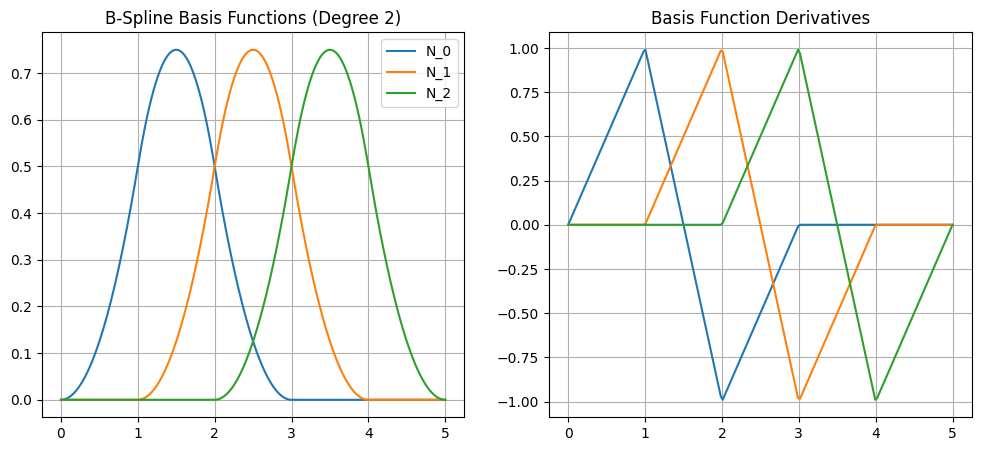

In [14]:
degree = 2
knots = np.arange(0, 6, 1)
num_bases = len(knots) - degree - 1

t_eval = np.linspace(0, 5, 200)

plt.figure(figsize=(12, 5))

# Plot Basis Functions
plt.subplot(1, 2, 1)
for i in range(num_bases):
    vals = [basis_function(t, i, degree, knots) for t in t_eval]
    plt.plot(t_eval, vals, label=f'N_{i}')
plt.title(f'B-Spline Basis Functions (Degree {degree})')
plt.grid(True)
plt.legend()

# Plot Derivatives
plt.subplot(1, 2, 2)
for i in range(num_bases):
    vals = [basis_derivative(t, i, degree, knots) for t in t_eval]
    plt.plot(t_eval, vals, label=f'N\'_{i}')
plt.title('Basis Function Derivatives')
plt.grid(True)

plt.show()

## 2. Generating Radar Point Cloud Data
Real radar sensors return a **point cloud** of detections. For a single scan at timestamp $t_k$, we might receive multiple detections with varying Doppler velocities (due to noise, different scattering centers, or clutter).

We simulate this by grouping detections at specific scan times.

Generated 137 detections across 25 scans.


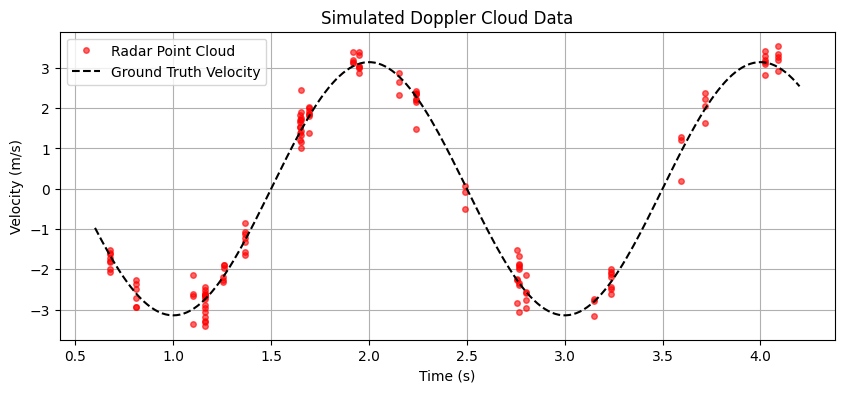

In [15]:
# Define Domain
knots = np.arange(0, 5, 0.2)
degree = 3
t_min, t_max = knots[degree], knots[-degree-1]

# Ground Truth: Sine Wave Position -> Cosine Wave Velocity
def ground_truth_pos(t):
    return np.sin(2 * np.pi * 0.5 * t)

def ground_truth_vel(t):
    return 2 * np.pi * 0.5 * np.cos(2 * np.pi * 0.5 * t)

# Simulate Radar Point Cloud
num_scans = 25
avg_points_per_scan = 5

# Generate random scan times
scan_times = np.sort(np.random.uniform(t_min, t_max, num_scans))

t_meas_list = []
v_meas_list = []

for t in scan_times:
    # Random number of points for this scan (e.g., 3 to 8 points)
    n_points = np.random.randint(max(1, avg_points_per_scan - 2), avg_points_per_scan + 4)
    
    # True velocity at this scan time
    v_true = ground_truth_vel(t)
    
    # Add noise variance to create a "spread" of points
    noise = np.random.normal(0, 0.3, n_points)
    v_points = v_true + noise
    
    # Append to flattened lists
    t_meas_list.extend([t] * n_points)
    v_meas_list.extend(v_points)

# Convert to numpy arrays for the solver
t_samples = np.array(t_meas_list)
v_measured = np.array(v_meas_list)

print(f"Generated {len(v_measured)} detections across {num_scans} scans.")

plt.figure(figsize=(10, 4))
plt.plot(t_samples, v_measured, 'r.', markersize=8, alpha=0.6, label='Radar Point Cloud')
t_plot = np.linspace(t_min, t_max, 200)
plt.plot(t_plot, ground_truth_vel(t_plot), 'k--', label='Ground Truth Velocity')
plt.legend()
plt.title('Simulated Doppler Cloud Data')
plt.xlabel('Time (s)')
plt.ylabel('Velocity (m/s)')
plt.grid(True)
plt.show()

## 3. The Matrix Formulation
We want to solve $v \approx H \cdot P$.

### Definitions & Dimensions
*   **$v$ (Measurement Vector)**: The vector of measured Doppler velocities.
    *   Shape: $(N, 1)$ where $N$ is the number of radar detections (e.g., 60).
*   **$P$ (Control Points)**: The unknown vector of B-Spline control points we want to solve for.
    *   Shape: $(K, 1)$ where $K$ is the number of basis functions ($K = \text{num\_knots} - \text{degree} - 1$).
*   **$H$ (Design Matrix / Jacobian)**: The matrix mapping control points to velocity.
    *   Shape: $(N, K)$.

Since our measurements are velocities, the matrix $H$ contains the **derivatives** of the basis functions,
so that $S'(t) = H \cdot P$:

$$ H_{k,i} = N'_{i,p}(t_k) $$

where $t_k$ is the timestamp of the $k$-th measurement and $i$ is the index of the $i$-th basis function.

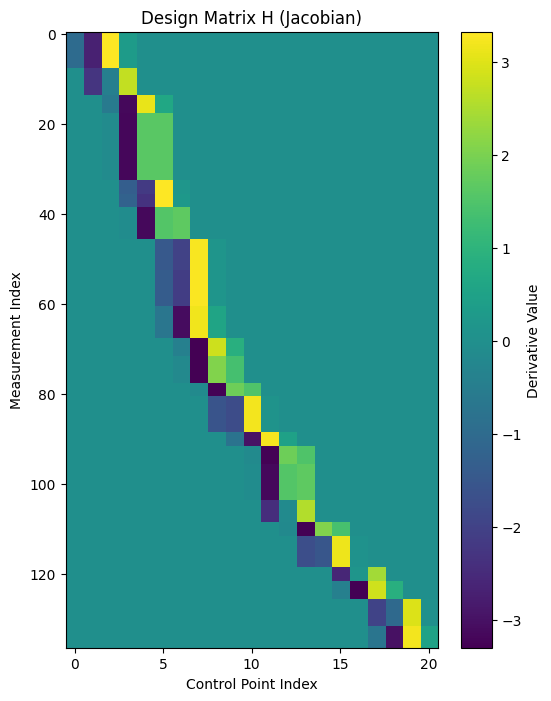

In [16]:
def generate_design_matrix(times, knots, degree):
    num_bases = len(knots) - degree - 1
    H = np.zeros((len(times), num_bases))
    
    for row, t in enumerate(times):
        for col in range(num_bases):
            # Optimization: Only evaluate if t is in support
            # Support of N_{i,p} is [u_i, u_{i+p+1})
            if knots[col] <= t < knots[col+degree+1]:
                H[row, col] = basis_derivative(t, col, degree, knots)
                
    return H

H = generate_design_matrix(t_samples, knots, degree)

# Visualize the Matrix Structure
plt.figure(figsize=(6, 8))
plt.imshow(H, aspect='auto', cmap='viridis')
plt.colorbar(label='Derivative Value')
plt.title('Design Matrix H (Jacobian)')
plt.xlabel('Control Point Index')
plt.ylabel('Measurement Index')
plt.show()

## 4. Optimization with Regularization
We solve for control points $P$ by minimizing:

$$ J = || H P - v ||^2 + \lambda || P ||^2 $$

Usually, we use a roughness matrix $Q$ for regularization to minimize acceleration or jerk, but for simplicity here we use Tikhonov regularization (minimizing the norm of P). 

In [17]:
lambda_reg = 0.5
num_bases = H.shape[1]

# Regularization Matrix (Identity for simple Tikhonov)
Reg = np.eye(num_bases) * np.sqrt(lambda_reg)

# Stack Matrices for Least Squares
lhs = np.vstack([H, Reg])
rhs = np.concatenate([v_measured, np.zeros(num_bases)])

# Solve
control_points, residuals, _, _ = np.linalg.lstsq(lhs, rhs, rcond=None)

print("Solved Control Points defined.")

Solved Control Points defined.


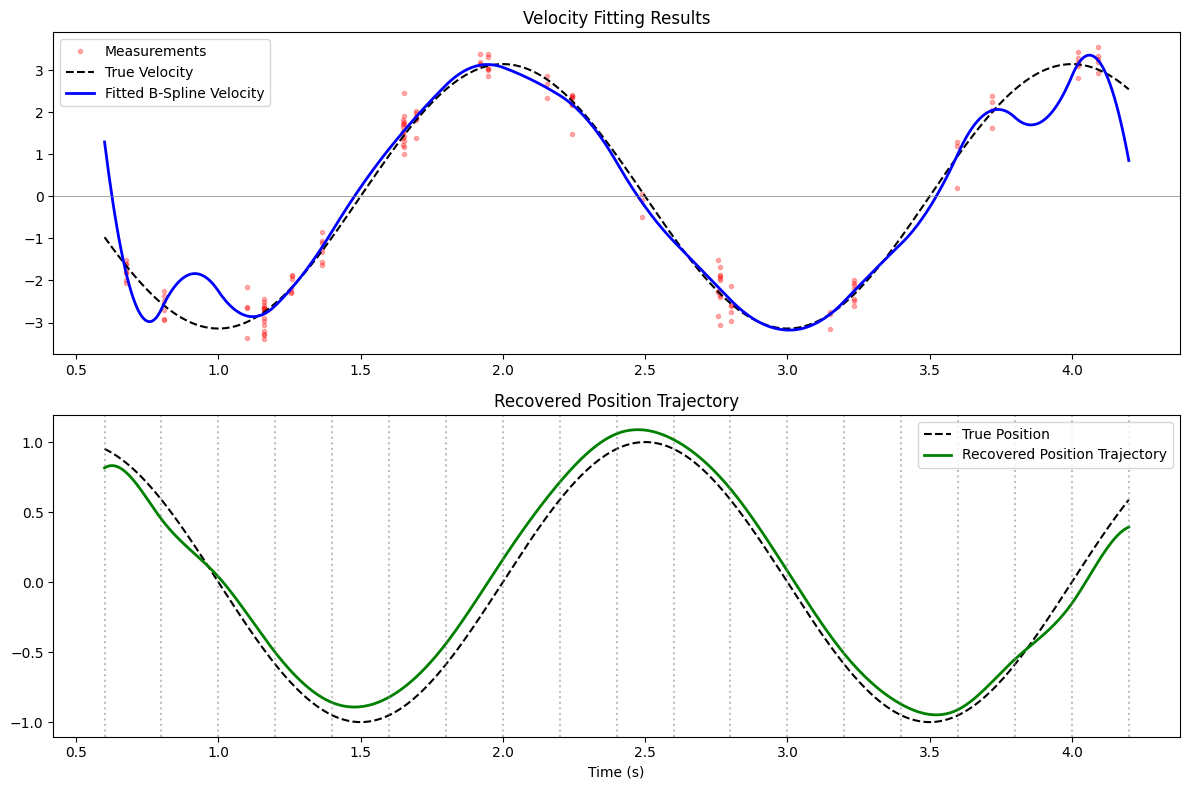

In [18]:
# Reconstruct Results
t_eval = np.linspace(t_min, t_max, 500)

# Reconstruct Velocity S'(t)
v_fit = []
for t in t_eval:
    val = 0
    for i in range(num_bases):
         val += control_points[i] * basis_derivative(t, i, degree, knots)
    v_fit.append(val)

# Reconstruct Position S(t)
pos_fit = []
for t in t_eval:
    val = 0
    for i in range(num_bases):
         val += control_points[i] * basis_function(t, i, degree, knots)
    pos_fit.append(val)

plt.figure(figsize=(12, 8))

# Plot Velocity Fit
plt.subplot(2, 1, 1)
plt.plot(t_samples, v_measured, 'r.', label='Measurements', alpha=0.3)
plt.plot(t_eval, ground_truth_vel(t_eval), 'k--', label='True Velocity')
plt.plot(t_eval, v_fit, 'b-', linewidth=2, label='Fitted B-Spline Velocity')
plt.legend()
plt.axhline(0, color='gray', linewidth=0.5)
plt.title('Velocity Fitting Results')

# Plot Recovered Position
plt.subplot(2, 1, 2)
plt.plot(t_eval, ground_truth_pos(t_eval), 'k--', label='True Position')
plt.plot(t_eval, pos_fit, 'g-', linewidth=2, label='Recovered Position Trajectory')
# Note: Position is recovered up to a constant integration constant shift
plt.legend()
plt.title('Recovered Position Trajectory')
plt.xlabel('Time (s)')

# Visualize Knots
for k in knots:
    if t_min <= k <= t_max:
        plt.axvline(k, color='gray', linestyle=':', alpha=0.5)

plt.tight_layout()
plt.show()

## 5. Sensor Fusion: Adding Accelerometer Data
To improve the trajectory estimation, we can fuse the Doppler velocity data with **accelerometer** measurements.
The accelerometer measures the second derivative of the position $S''(t)$.

We need to implement the second derivative of the B-Spline basis functions:
$$ N''_{i,p}(t) = p \left( \frac{N'_{i,p-1}(t)}{u_{i+p} - u_i} - \frac{N'_{i+1,p-1}(t)}{u_{i+p+1} - u_{i+1}} \right) $$

In [19]:
def basis_second_derivative(t, i, p, knots):
    """
    Calculate N''_{i,p}(t) recursively.
    """
    if p < 2:
        return 0.0
        
    # Term 1
    denom1 = knots[i+p] - knots[i]
    if denom1 == 0:
        term1 = 0.0
    else:
        term1 = basis_derivative(t, i, p-1, knots) / denom1
        
    # Term 2
    denom2 = knots[i+p+1] - knots[i+1]
    if denom2 == 0:
        term2 = 0.0
    else:
        term2 = basis_derivative(t, i+1, p-1, knots) / denom2
        
    return p * (term1 - term2)

### 5.1 Simulating Accelerometer Data
We assume the accelerometer provides high-frequency measurements of $S''(t)$.

Generated 360 accelerometer samples at 100 Hz


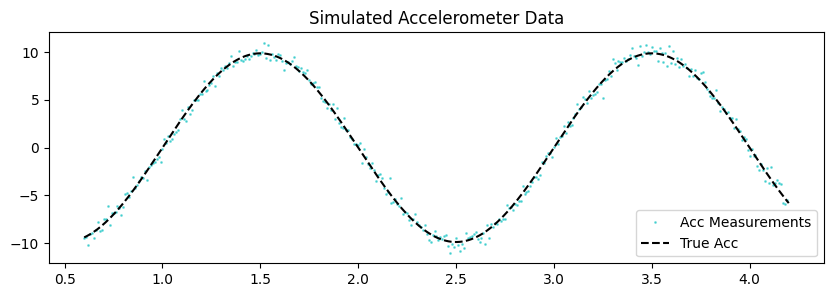

In [20]:
def ground_truth_acc(t):
    # Derivative of Velocity (Cosine) -> -Sine
    # v(t) = 2*pi*0.5 * cos(2*pi*0.5*t)
    # a(t) = -(2*pi*0.5)^2 * sin(2*pi*0.5*t)
    freq = 0.5
    omega = 2 * np.pi * freq
    return - (omega**2) * np.sin(omega * t)

# Generate IMU/Accelerometer Data (Higher Rate)
imu_rate = 100 # Hz
t_imu = np.arange(t_min, t_max, 1.0/imu_rate)
a_true = ground_truth_acc(t_imu)

# Add Noise
acc_noise_std = 0.5
a_measured = a_true + np.random.normal(0, acc_noise_std, len(t_imu))

print(f"Generated {len(a_measured)} accelerometer samples at {imu_rate} Hz")

plt.figure(figsize=(10, 3))
plt.plot(t_imu, a_measured, 'c.', markersize=2, label='Acc Measurements', alpha=0.5)
plt.plot(t_eval, ground_truth_acc(t_eval), 'k--', label='True Acc')
plt.legend()
plt.title('Simulated Accelerometer Data')
plt.show()

### 5.2 Joint Optimization
We want to solve for control points $P$ by minimizing a joint cost function involving velocity errors, acceleration errors, and regularization:

$$ J(P) = \underbrace{|| H_{vel} P - v ||^2}_{\text{Velocity Error}} + \underbrace{w \cdot || H_{acc} P - a ||^2}_{\text{Weighted Acc Error}} + \underbrace{\lambda \cdot || P ||^2}_{\text{Regularization}} $$

Standard least-squares solvers minimize an objective of the form $|| Ax - b ||^2$. To fit our weighted terms into this form, we use the property that weighted sums of squares can be written as the norm of a scaled vector: $w ||x||^2 = ||\sqrt{w} x||^2$.

#### The Stacking Trick
We stack the linear equations vertically. Each block represents one term in the cost function:

1.  **Velocity Term**: $H_{vel} P \approx v$
    *   This is the standard term. No scaling needed (weight = 1).
2.  **Acceleration Term**: $H_{acc} P \approx a$
    *   We want this to have weight $w$. We multiply the entire equation (both sides) by $\sqrt{w}$.
    *   $\sqrt{w} H_{acc} P \approx \sqrt{w} a$
    *   The squared error becomes: $|| \sqrt{w}H_{acc} P - \sqrt{w}a ||^2 = (\sqrt{w})^2 || H_{acc}P - a ||^2 = w || H_{acc}P - a ||^2$. Exactly what we wanted.
3.  **Regularization Term**: $P \approx 0$
    *   We want to penalize the magnitude of $P$ with weight $\lambda$. This is equivalent to saying measured P should be 0.
    *   We multiply by $\sqrt{\lambda}$:
    *   $\sqrt{\lambda} I P \approx \sqrt{\lambda} \cdot 0$  (which is just vector 0)
    *   Squared error: $|| \sqrt{\lambda} I P - 0 ||^2 = \lambda || P ||^2$.

#### Final System
Stacking these creates one large system $A_{stack} P = b_{stack}$:

$$ \begin{bmatrix} H_{vel} \\ \sqrt{w} H_{acc} \\ \sqrt{\lambda} I \end{bmatrix} P = \begin{bmatrix} v_{meas} \\ \sqrt{w} a_{meas} \\ 0 \end{bmatrix} $$

In [21]:
def generate_acc_design_matrix(times, knots, degree):
    num_bases = len(knots) - degree - 1
    H_acc = np.zeros((len(times), num_bases))
    for row, t in enumerate(times):
        for col in range(num_bases):
             if knots[col] <= t < knots[col+degree+1]:
                 H_acc[row, col] = basis_second_derivative(t, col, degree, knots)
    return H_acc

H_acc = generate_acc_design_matrix(t_imu, knots, degree)

# Weights
w_acc = 0.1  # Relative weight of accelerometer data vs radar
lambda_reg = 0.1

# Stack Matrices
# 1. Velocity Block
H_vel = H  # From previous section

# 2. Acceleration Block (Weighted)
H_acc_weighted = H_acc * np.sqrt(w_acc)
a_meas_weighted = a_measured * np.sqrt(w_acc)

# 3. Regularization Block
Reg = np.eye(num_bases) * np.sqrt(lambda_reg)
b_reg = np.zeros(num_bases)

# Combine
LHS = np.vstack([H_vel, H_acc_weighted, Reg])
RHS = np.concatenate([v_measured, a_meas_weighted, b_reg])

# Solve Joint Problem
P_joint, _, _, _ = np.linalg.lstsq(LHS, RHS, rcond=None)

print("Solved Joint Control Points.")

Solved Joint Control Points.


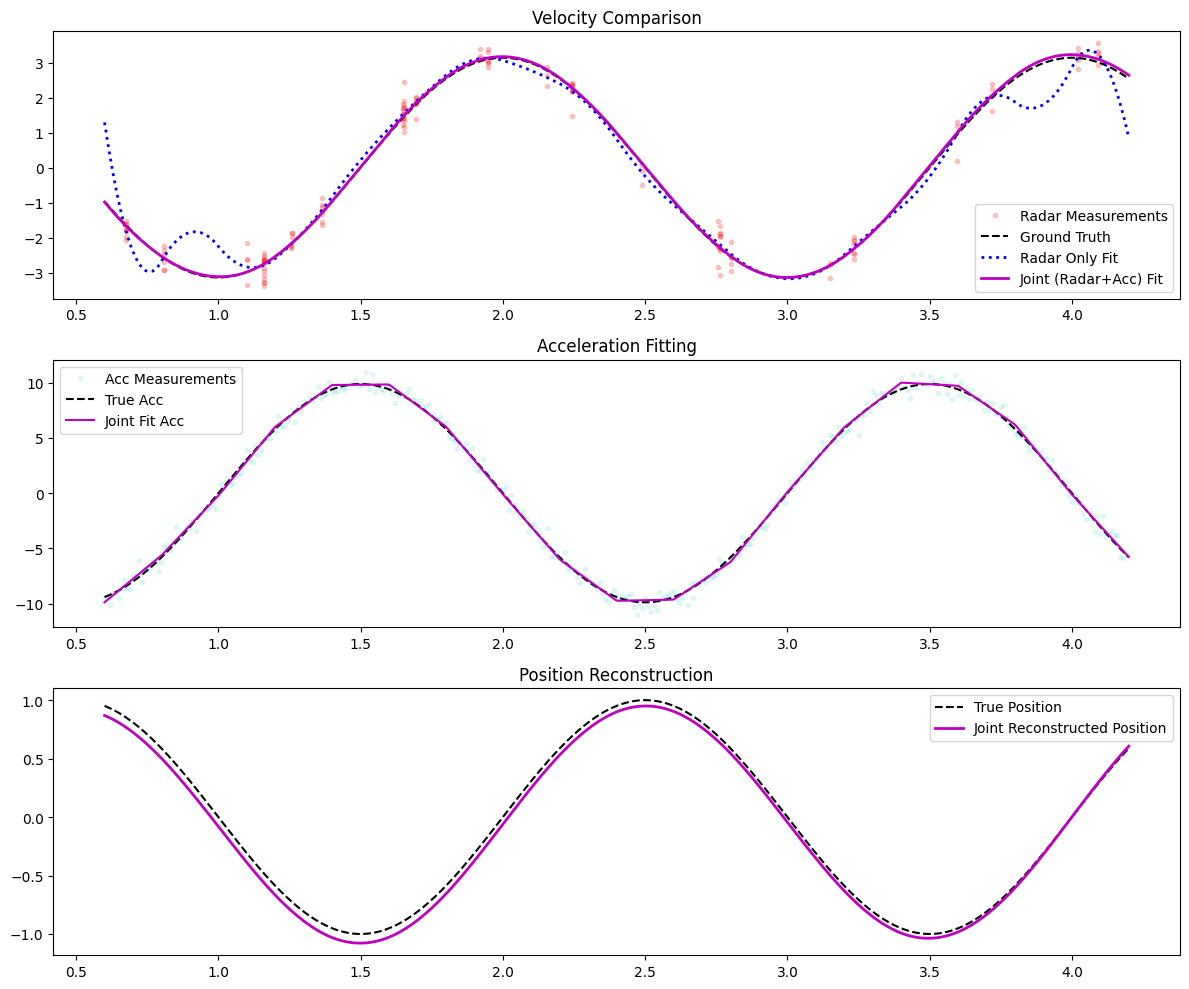

In [22]:
# Visualization Comparison
v_fit_joint = []
pos_fit_joint = []

for t in t_eval:
    val_v = 0
    val_p = 0
    for i in range(num_bases):
         val_v += P_joint[i] * basis_derivative(t, i, degree, knots)
         val_p += P_joint[i] * basis_function(t, i, degree, knots)
    v_fit_joint.append(val_v)
    pos_fit_joint.append(val_p)

plt.figure(figsize=(12, 10))

# Velocity Comparison
plt.subplot(3, 1, 1)
plt.plot(t_samples, v_measured, 'r.', alpha=0.2, label='Radar Measurements')
plt.plot(t_eval, ground_truth_vel(t_eval), 'k--', label='Ground Truth')
plt.plot(t_eval, v_fit, 'b:', linewidth=2, label='Radar Only Fit')
plt.plot(t_eval, v_fit_joint, 'm-', linewidth=2, label='Joint (Radar+Acc) Fit')
plt.legend()
plt.title('Velocity Comparison')

# Acceleration Check
plt.subplot(3, 1, 2)
plt.plot(t_imu, a_measured, 'c.', alpha=0.1, label='Acc Measurements')
plt.plot(t_eval, ground_truth_acc(t_eval), 'k--', label='True Acc')
# Recalculate fitted acceleration
a_fit_joint = []
for t in t_eval:
    val = 0
    for i in range(num_bases):
        val += P_joint[i] * basis_second_derivative(t, i, degree, knots)
    a_fit_joint.append(val)
plt.plot(t_eval, a_fit_joint, 'm-', label='Joint Fit Acc')
plt.legend()
plt.title('Acceleration Fitting')

# Position Comparison
plt.subplot(3, 1, 3)
plt.plot(t_eval, ground_truth_pos(t_eval), 'k--', label='True Position')
plt.plot(t_eval, pos_fit_joint, 'm-', linewidth=2, label='Joint Reconstructed Position')
plt.legend()
plt.title('Position Reconstruction')

plt.tight_layout()
plt.show()